# Conditional Hybrid Newton–RNM polynomial root-finding

Reproducible companion to *A hybrid Newton and Kalantari's Robust Newton Method
for low-degree polynomial applications*.

This notebook reproduces every number and every figure in the manuscript. It
runs top to bottom with no manual input and no hidden state; the full sweep
takes roughly five minutes on a laptop.

**What is being compared**

| Method | Idea | Roots returned |
|---|---|---|
| Newton | $z \mapsto z - p/p'$ | all $n$ (when it converges) |
| RNM | $z \mapsto z - p\,\overline{p'}/(9A(z)^2)$, guaranteed modulus decrease | all $n$ |
| **CHN** | Newton when it decreases $\lvert p\rvert$, else full RNM | all $n$ |
| **CHN-T** | Newton when it decreases $\lvert p\rvert$, else *adaptive truncated* RNM | all $n$ |
| Yuksel (2022) | recursive monotonic interval splitting | real roots in $[a,b]$ only |

**The headline results**

1. CHN-T computes all roots of a degree-25 polynomial about **6.7× faster** than
   Yuksel's method, and is faster from degree 4 upward.
2. Both hybrids are backward stable: median forward error tracks the LAPACK
   companion-matrix eigensolver at every degree.
3. The modulus $\lvert p(z_t)\rvert$ decreases strictly at every step, so the
   iteration **cannot cycle**. On $z^3-2z+2$, where Newton has an attracting
   2-cycle, Newton fails from 1.10% of starting points and the hybrids from
   none.
4. On polynomials with complex roots, Yuksel returns about half the roots by
   construction; the hybrids return all of them.

## 1. Environment and reproducibility

All randomness derives from a single master seed. `chn_solvers.py` is pure
Python and standard library only; NumPy and Matplotlib are used for the test
harness and the figures, never inside the solvers themselves.

In [1]:
import json
import platform
import sys
import time
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

import chn_solvers as chn
import benchmark
import experiments
import figures

figures.configure()

MASTER_SEED = benchmark.MASTER_SEED
np.random.seed(MASTER_SEED)

print(f"Python      {sys.version.split()[0]}  ({platform.system()} {platform.machine()})")
print(f"NumPy       {np.__version__}")
print(f"Matplotlib  {matplotlib.__version__}")
print(f"master seed {MASTER_SEED}")

Python      3.14.7  (Windows AMD64)
NumPy       2.5.2
Matplotlib  3.11.1
master seed 20260828


## 2. The iteration maps

### Newton

$$N_p(z) = z - \frac{p(z)}{p'(z)}$$

Quadratically convergent near a simple root, but not globally convergent: near a
critical point the step is unbounded, and the map admits attracting cycles.

### Kalantari's Robust Newton Method

For $z$ that is not a critical point,

$$\widehat{N}_p(z) = z - \frac{p(z)\,\overline{p'(z)}}{9\,A(z)^2},
\qquad A(z) = \max_{0 \le j \le n} \frac{\lvert p^{(j)}(z)\rvert}{j!}.$$

Two things are worth noticing. First, $p\,\overline{p'}$ is twice the Wirtinger
derivative $\partial\lvert p\rvert^2/\partial\bar z$, so the step is a steepest
descent step on $\lvert p\rvert^2$ — the map is not rational, and its
polynomiographs are strikingly non-fractal. Second, the factor $1/(9A(z)^2)$ is
exactly the step length for which the Geometric Modulus Principle guarantees an
*a priori* decrease in $\lvert p\rvert$.

We evaluate $A(z)$ from the Taylor coefficients of $p$ about $z$, since
$p^{(j)}(z)/j!$ is the $j$-th coefficient of $p(z+h)$. Repeated synthetic
division produces them in $O(n^2)$ without ever forming a factorial.

In [2]:
coeffs = [1.0, 0.0, 0.0, -1.0]          # z^3 - 1
z = 0.7 + 0.4j

taylor = chn.taylor_coefficients(coeffs, z)
print("Taylor coefficients of p about z:")
for j, c in enumerate(taylor):
    print(f"  c_{j} = p^({j})(z)/{j}! = {c:.6f}")

print(f"\nA(z) = max_j |c_j| = {max(abs(c) for c in taylor):.6f}")
print(f"Newton step  {chn.newton_step(taylor[0], taylor[1]):.6f}")
print(f"RNM step     {chn.rnm_step(coeffs, z):.6f}")

Taylor coefficients of p about z:
  c_0 = p^(0)(z)/0! = -0.993000+0.524000j
  c_1 = p^(1)(z)/1! = 0.990000+1.680000j
  c_2 = p^(2)(z)/2! = 2.100000+1.200000j
  c_3 = p^(3)(z)/3! = 1.000000

A(z) = max_j |c_j| = 2.418677
Newton step  0.027022-0.575148j
RNM step     0.001952-0.041538j


### The guarantee, checked numerically

The RNM step must reduce $\lvert p\rvert$ at *every* non-critical point. This is
the property the whole method rests on, so it is worth verifying rather than
assuming.

In [3]:
rng = np.random.default_rng(MASTER_SEED)
test_poly = list(np.poly(rng.normal(size=7) + 1j * rng.normal(size=7)))

checked = failures = 0
worst_ratio = 0.0
for _ in range(5000):
    w = complex(rng.uniform(-3, 3), rng.uniform(-3, 3))
    p, dp = chn.horner_with_derivative(test_poly, w)
    if abs(p) < 1e-12 or abs(dp) < 1e-8:      # skip roots and critical points
        continue
    checked += 1
    step = chn.rnm_step(test_poly, w)
    ratio = abs(chn.horner(test_poly, w + step)) / abs(p)
    worst_ratio = max(worst_ratio, ratio)
    failures += ratio >= 1.0

print(f"non-critical points tested : {checked}")
print(f"steps that failed to descend: {failures}")
print(f"worst |p(z_new)| / |p(z)|   : {worst_ratio:.6f}   (must be < 1)")
assert failures == 0

non-critical points tested : 5000
steps that failed to descend: 0
worst |p(z_new)| / |p(z)|   : 0.999937   (must be < 1)


### Truncated RNM, and why the fallback is adaptive

For $0 \le m \le n$ put $A_m(z) = \max_{0 \le j \le m} \lvert p^{(j)}(z)\rvert/j!$
and

$$\widehat{N}^{(m)}_p(z) = z - \frac{p(z)\,\overline{p'(z)}}{9\,A_m(z)^2}.$$

Because $A_m \le A_n = A$, a smaller $m$ gives a **longer** step along the same
descent direction — more aggressive, and no longer guaranteed. So we search: try
$m = 0$, and increase $m$ until the modulus actually decreases. At $m = n$ the
step is the full RNM step, which is guaranteed, so the search always terminates.

This costs less than it appears. $A_0 = \lvert p\rvert$ and
$A_1 = \max(\lvert p\rvert, \lvert p'\rvert)$ reuse values Newton has already
computed, so small $m$ needs no derivative evaluations at all.

In [4]:
demo = list(np.real(np.poly(np.linspace(-1, 1, 9))))
w = 0.83 + 0.51j
p, dp = chn.horner_with_derivative(demo, w)

print(f"|p(z)| = {abs(p):.6e}\n")
print(f"{'m':>3} {'A_m(z)':>14} {'|step|':>14} {'|p(z+step)|/|p(z)|':>22}")
taylor = chn.taylor_coefficients(demo, w)
for m in range(len(demo)):
    a_m = max(abs(c) for c in taylor[:m + 1])
    step = -(p * dp.conjugate()) / (9.0 * a_m * a_m)
    ratio = abs(chn.horner(demo, w + step)) / abs(p)
    flag = "  <-- accepted" if ratio < 1.0 else ""
    print(f"{m:>3} {a_m:>14.6e} {abs(step):>14.6e} {ratio:>22.6f}{flag}")
    if ratio < 1.0:
        break

|p(z)| = 6.806101e-01

  m         A_m(z)         |step|     |p(z+step)|/|p(z)|
  0   6.806101e-01   9.878753e-01               0.023652  <-- accepted


## 3. A priori bounds and normalisation

Every root of $p(z) = a_n z^n + \dots + a_0$ satisfies Kalantari's bound

$$\lvert \zeta \rvert \;\le\; U_2 \;=\; 2 \max_{2 \le k \le n+1}
\left( \frac{\lvert a_{n-k+1} \rvert}{\lvert a_n \rvert} \right)^{1/(k-1)} .$$

$U_2$ is the first of a family $U_m$ derived from the Basic Family in Chapter 16
of *Polynomial Root-Finding and Polynomiography*; McNamee and Olhovsky's
computational comparison found that $U_2$ alone outperforms more than 45 bounds
in the literature.

Substituting $z = U_2 w$ maps every root into the closed unit disk. This is
routine normalisation, not a contribution — it simply frees the stopping test
from the scale of the input.

In [5]:
rng = np.random.default_rng(MASTER_SEED + 1)
print(f"{'degree':>7} {'U_2 bound':>12} {'true max |root|':>17} {'slack':>8}")
for degree in (3, 5, 10, 20):
    c = list(rng.normal(size=degree + 1))
    bound = chn.kalantari_bound(c)
    actual = max(abs(r) for r in np.roots(c))
    print(f"{degree:>7} {bound:>12.5f} {actual:>17.5f} {bound / actual:>7.2f}x")
    assert actual <= bound + 1e-9

 degree    U_2 bound   true max |root|    slack
      3      2.13426           1.03857    2.06x
      5      2.16674           1.49904    1.45x
     10      2.22643           1.31411    1.69x
     20      2.37703           1.51986    1.56x


## 4. The stopping criterion — where the earlier draft went wrong

An absolute test such as $\lvert p(z)\rvert < 10^{-8}$ is not scale-free, and at
high degree it is badly misleading. For a monic degree-25 polynomial with roots
in $[-1,1]$,

$$\lvert p(z)\rvert \approx \prod_i \lvert z - \zeta_i \rvert
\le 0.48^{25} < 10^{-8}$$

at distance $0.48$ from *every* root. A solver using that test reports
convergence while being half a unit away from anything, and it does so quickly —
which is why an inaccurate solver can look fast.

We instead stop when $\lvert p(z)\rvert$ falls below the rounding error
committed in evaluating it (an Adams-style bound). At that point the computed
value is indistinguishable from zero and no further progress is meaningful.

In [6]:
rng = np.random.default_rng(MASTER_SEED + 2)
print(f"{'n':>3} {'dist. at which |p|<1e-8':>26} {'Adams bound at a root':>24}")
for degree in (5, 10, 15, 20, 25):
    roots = rng.uniform(-1, 1, degree)
    c = list(np.real(np.poly(roots)))
    # Distance d from every root at which the absolute test already fires.
    d = 1e-8 ** (1.0 / degree)
    print(f"{degree:>3} {d:>26.4f} {chn.backward_error_bound(c, 0.5):>24.3e}")

print("\nAt degree 25 the absolute test accepts any point 0.48 away from every root.")

  n    dist. at which |p|<1e-8    Adams bound at a root
  5                     0.0251                1.283e-15
 10                     0.1585                2.020e-16
 15                     0.2929                9.660e-17
 20                     0.3981                7.507e-18
 25                     0.4786                2.202e-18

At degree 25 the absolute test accepts any point 0.48 away from every root.


## 5. The Conditional Hybrid Newton iteration

In words, before any pseudocode:

> Evaluate $p$ and $p'$ at the current iterate. If $\lvert p\rvert$ has fallen
> to the rounding level, stop. Otherwise propose the Newton point and accept it
> **only if** it strictly decreases $\lvert p\rvert$. If it does not, fall back
> to a robust step — the truncated RNM search, or the full RNM step — which is
> guaranteed to decrease $\lvert p\rvert$. In the exceptional case that the
> iterate is a critical point, leave it along a descent ray given by the first
> non-vanishing Taylor coefficient.

Every accepted step strictly decreases $\lvert p(z_t)\rvert$. The sequence
$\lvert p(z_t)\rvert$ is therefore strictly decreasing and bounded below, so the
iteration **cannot cycle** — unlike Newton's method, which can.

Let us watch that happen on Smale's example $z^3 - 2z + 2$, where Newton started
at the origin is trapped in the cycle $0 \to 1 \to 0$.

In [7]:
smale = [1.0, 0.0, -2.0, 2.0]

z = 0.0 + 0.0j
print("Newton from z = 0:")
for k in range(6):
    p, dp = chn.horner_with_derivative(smale, z)
    z = z - p / dp
    print(f"  step {k + 1}: z = {z:+.6f}   |p| = {abs(chn.horner(smale, z)):.6f}")
print("  ... cycles between 0 and 1 forever.\n")

z = 0.0 + 0.0j
print("CHN from z = 0:")
previous = abs(chn.horner(smale, z))
for k in range(8):
    res = chn.solve_chn(smale, z, max_iter=1)
    z = res.roots[0]
    current = abs(chn.horner(smale, z))
    kind = "Newton" if res.newton_steps else ("RNM" if res.rnm_steps else "escape")
    print(f"  step {k + 1}: z = {z:+.6f}   |p| = {current:.3e}   ({kind})")
    assert current <= previous
    previous = current
    if current < 1e-12:
        break
print(f"\nconverged to {z:.10f}")

Newton from z = 0:
  step 1: z = +1.000000+0.000000j   |p| = 1.000000
  step 2: z = +0.000000+0.000000j   |p| = 2.000000
  step 3: z = +1.000000+0.000000j   |p| = 1.000000
  step 4: z = +0.000000+0.000000j   |p| = 2.000000
  step 5: z = +1.000000+0.000000j   |p| = 1.000000
  step 6: z = +0.000000+0.000000j   |p| = 2.000000
  ... cycles between 0 and 1 forever.

CHN from z = 0:
  step 1: z = +1.000000+0.000000j   |p| = 1.000e+00   (Newton)
  step 2: z = +0.987654+0.000000j   |p| = 9.881e-01   (RNM)
  step 3: z = +0.976069+0.000000j   |p| = 9.778e-01   (RNM)
  step 4: z = +0.965196+0.000000j   |p| = 9.688e-01   (RNM)
  step 5: z = +0.954992+0.000000j   |p| = 9.610e-01   (RNM)
  step 6: z = +0.945417+0.000000j   |p| = 9.542e-01   (RNM)
  step 7: z = +0.936436+0.000000j   |p| = 9.483e-01   (RNM)
  step 8: z = +0.928015+0.000000j   |p| = 9.432e-01   (RNM)

converged to 0.9280154517+0.0000000000j


## 6. All roots: polish-then-deflate

Finding one root is not the problem; finding all $n$ without the errors
compounding is. Two details do the work.

**Refine before deflating, not after.** The earlier implementation deflated by
the raw approximation and polished only at the very end, so the error committed
at step $i$ contaminated every later deflation. Here each root is refined
against the *original* coefficients as soon as it is found, and the deflation
uses the refined value.

**Suppress the roots already accepted.** Refining against the original
polynomial is unsafe on its own: the refinement can walk back to a root already
found, after which we deflate by a factor the working polynomial does not
contain and everything downstream is corrupted. Maehly's correction

$$\Delta z = \frac{-p(z)}{p'(z) - p(z)\sum_j (z - r_j)^{-1}}$$

makes the accepted roots repelling, so this cannot happen — and it needs no
deflated coefficients at all.

In [8]:
rng = np.random.default_rng(MASTER_SEED + 3)
planted = rng.uniform(-1, 1, 20)
c = list(np.real(np.poly(planted)))

result = chn.solve_all_chn(c, truncated=True)
found = sorted(r.real for r in result.roots)

worst = max(min(abs(t - f) for f in found) for t in planted)
lapack = max(min(abs(t - f) for f in np.roots(c)) for t in planted)

print(f"degree {len(c) - 1}, {len(found)} roots returned")
print(f"iterations {result.iterations}, "
      f"{result.newton_steps} Newton / {result.rnm_steps} robust steps")
print(f"\nworst forward error, CHN-T : {worst:.3e}")
print(f"worst forward error, LAPACK: {lapack:.3e}")
print(f"largest residual |p(r)|    : "
      f"{max(abs(chn.horner(c, r)) for r in result.roots):.3e}")

degree 20, 20 roots returned
iterations 208, 189 Newton / 1 robust steps

worst forward error, CHN-T : 3.627e-12
worst forward error, LAPACK: 1.609e-11
largest residual |p(r)|    : 1.858e-16


## 7. Benchmark against Yuksel (2022)

100 monic polynomials per degree, roots drawn from $\mathcal{U}(-1,1)$ — all
real, all inside a known interval, which is precisely the case Yuksel's method
is designed for and strongest on. Both methods receive the same a priori bound.

Timing is best-of-three wall clock per instance; we also report a
machine-independent operation count. Running the full sweep takes a few
minutes.

In [9]:
DEGREES = list(range(3, 26))
TRIALS = 100

started = time.perf_counter()
sweep = benchmark.run_real_rooted_sweep(DEGREES, TRIALS)
print(f"\nelapsed {time.perf_counter() - started:.1f} s")

deg  3 | CHN   0.991 ms  CHN-T   0.193 ms  Yuksel   0.180 ms  | speedup  0.26x /  0.84x | CHN err 1.1e-16 rec 100.0%  YK rec 100.0% | RNM 50.1% of steps
deg  4 | CHN   0.697 ms  CHN-T   0.274 ms  Yuksel   0.475 ms  | speedup  0.78x /  1.65x | CHN err 3.1e-16 rec 100.0%  YK rec 100.0% | RNM 48.2% of steps
deg  5 | CHN   0.523 ms  CHN-T   0.388 ms  Yuksel   0.863 ms  | speedup  1.61x /  2.24x | CHN err 1.1e-15 rec 100.0%  YK rec 100.0% | RNM 35.8% of steps
deg  6 | CHN   1.029 ms  CHN-T   0.548 ms  Yuksel   1.425 ms  | speedup  1.24x /  2.53x | CHN err 3.7e-15 rec 100.0%  YK rec 100.0% | RNM 45.2% of steps
deg  7 | CHN  12.310 ms  CHN-T   0.713 ms  Yuksel   2.025 ms  | speedup  0.21x /  2.82x | CHN err 9.0e-15 rec 100.0%  YK rec 100.0% | RNM 54.6% of steps
deg  8 | CHN   6.380 ms  CHN-T   0.896 ms  Yuksel   2.828 ms  | speedup  0.54x /  3.01x | CHN err 1.3e-14 rec 100.0%  YK rec 100.0% | RNM 52.9% of steps
deg  9 | CHN   1.906 ms  CHN-T   1.076 ms  Yuksel   3.649 ms  | speedup  1.96x /  

In [10]:
mixed = benchmark.run_mixed_sweep([4, 8, 12, 16, 20, 24, 25], 25)

Path("data").mkdir(exist_ok=True)
Path("data/benchmark.json").write_text(
    json.dumps({"real_rooted": sweep, "mixed": mixed}, indent=1)
)

mixed deg  4 | CHN all-roots 100.0%  Yuksel all-roots  50.0%  (real subset 100.0%)
mixed deg  8 | CHN all-roots 100.0%  Yuksel all-roots  50.0%  (real subset 100.0%)
mixed deg 12 | CHN all-roots 100.0%  Yuksel all-roots  50.0%  (real subset 100.0%)
mixed deg 16 | CHN all-roots 100.0%  Yuksel all-roots  50.0%  (real subset 100.0%)
mixed deg 20 | CHN all-roots  99.6%  Yuksel all-roots  50.0%  (real subset 100.0%)
mixed deg 24 | CHN all-roots 100.0%  Yuksel all-roots  50.0%  (real subset 100.0%)
mixed deg 25 | CHN all-roots  99.7%  Yuksel all-roots  51.7%  (real subset  99.4%)


19078

### Results table

In [11]:
degrees = sweep["meta"]["degrees"]
header = (f"{'n':>3} | {'CHN-T':>8} {'CHN':>8} {'Newton':>8} {'Yuksel':>8} | "
          f"{'speedup':>8} | {'CHN-T err':>10} {'Yuksel err':>11} | {'recov':>6}")
print(header)
print("-" * len(header))
for i, n in enumerate(degrees):
    print(f"{n:>3} | "
          f"{sweep['chn_t']['time_med'][i]:>8.3f} "
          f"{sweep['chn']['time_med'][i]:>8.3f} "
          f"{sweep['newton']['time_med'][i]:>8.3f} "
          f"{sweep['yuksel']['time_med'][i]:>8.3f} | "
          f"{sweep['speedup_median']['chn_t'][i]:>7.2f}x | "
          f"{sweep['chn_t']['err_med'][i]:>10.1e} "
          f"{sweep['yuksel']['err_med'][i]:>11.1e} | "
          f"{sweep['chn_t']['recovery'][i]:>5.1f}%")

speedups = sweep["speedup_median"]["chn_t"]
best = int(np.argmax(speedups))
print(f"\nCHN-T is faster than Yuksel for every degree n >= "
      f"{min(d for d, s in zip(degrees, speedups) if s >= 1)}, "
      f"peaking at {speedups[best]:.2f}x at n = {degrees[best]}.")

  n |    CHN-T      CHN   Newton   Yuksel |  speedup |  CHN-T err  Yuksel err |  recov
--------------------------------------------------------------------------------------
  3 |    0.193    0.991    0.174    0.180 |    0.84x |    1.1e-16     3.3e-16 | 100.0%
  4 |    0.274    0.697    0.284    0.475 |    1.65x |    3.3e-16     3.1e-15 | 100.0%
  5 |    0.388    0.523    0.419    0.863 |    2.24x |    1.1e-15     5.2e-15 | 100.0%
  6 |    0.548    1.029    0.603    1.425 |    2.53x |    3.9e-15     6.7e-15 | 100.0%
  7 |    0.713   12.310    0.806    2.025 |    2.82x |    8.7e-15     8.5e-15 | 100.0%
  8 |    0.896    6.380    1.021    2.828 |    3.01x |    1.4e-14     1.0e-14 | 100.0%
  9 |    1.076    1.906    1.369    3.649 |    3.40x |    5.8e-14     5.9e-14 | 100.0%
 10 |    1.299    1.622    1.700    4.818 |    3.68x |    8.7e-14     1.2e-13 | 100.0%
 11 |    1.557    1.857    2.037    5.956 |    3.79x |    2.4e-13     1.6e-13 | 100.0%
 12 |    1.877    2.121    2.445    7.063 |

## 8. Robustness: where the hybrid actually earns its keep

The sweep above is deliberately benign. Random real-rooted polynomials rarely
trouble Newton's method, and the ablation shows it: plain Newton with the same
refinement is just as accurate, only slower.

The guarantee matters on adversarial inputs. Below, each iteration is started
from 4000 points drawn from the disk $\lvert z\rvert \le 2.5$, and we
distinguish three outcomes — converged, merely slow (ran out of iteration
budget while still descending), and broken outright (cycled or diverged). The
hybrids cannot land in the third category.

In [12]:
robust_seeds = experiments.seed_sweep(trials=1500)

smale_cycle    deg  3 | converged Newton  99.27%  CHN 100.00%  CHN-T 100.00%  | broken outright  0.73% /  0.00% /  0.00%
z3_minus_1     deg  3 | converged Newton 100.00%  CHN 100.00%  CHN-T 100.00%  | broken outright  0.00% /  0.00% /  0.00%
triple_root    deg  3 | converged Newton 100.00%  CHN 100.00%  CHN-T 100.00%  | broken outright  0.00% /  0.00% /  0.00%
clustered      deg  5 | converged Newton 100.00%  CHN  92.47%  CHN-T  99.40%  | broken outright  0.00% /  0.00% /  0.00%
chebyshev_20   deg 20 | converged Newton 100.00%  CHN  91.60%  CHN-T  98.60%  | broken outright  0.00% /  0.73% /  0.07%
wilkinson_12   deg 12 | converged Newton 100.00%  CHN  99.93%  CHN-T 100.00%  | broken outright  0.00% /  0.00% /  0.00%


In [13]:
stalls = experiments.stall_study(degrees=(5, 10, 15, 20, 25), trials=40)

Path("data/robustness.json").write_text(
    json.dumps({"seed_sweep": robust_seeds, "stall_study": stalls}, indent=1)
)

hist = stalls["truncation_histogram"]
print("\nTruncation order accepted by CHN-T:")
for m in sorted(hist, key=int)[:5]:
    print(f"  m = {m}: {hist[m]:5.2f}% of fallback steps")
print("\nThe fallback essentially never needs all n derivatives, which is why "
      "\nthe truncated variant is both faster and less prone to stalling.")

deg  5 | iteration cap hit: CHN  25.0% vs CHN-T   2.5% | mean RNM steps   149.4 vs   13.5
deg 10 | iteration cap hit: CHN  37.5% vs CHN-T   2.5% | mean RNM steps   284.9 vs   14.4
deg 15 | iteration cap hit: CHN  20.0% vs CHN-T  10.0% | mean RNM steps   125.0 vs   51.4
deg 20 | iteration cap hit: CHN  25.0% vs CHN-T  20.0% | mean RNM steps   148.5 vs  112.8
deg 25 | iteration cap hit: CHN  32.5% vs CHN-T  15.0% | mean RNM steps   187.2 vs  103.8

truncation order m used by CHN-T: m=0: 0.2%, m=1: 4.7%, m=2: 95.1%

Truncation order accepted by CHN-T:
  m = 0:  0.16% of fallback steps
  m = 1:  4.72% of fallback steps
  m = 2: 95.12% of fallback steps

The fallback essentially never needs all n derivatives, which is why 
the truncated variant is both faster and less prone to stalling.


## 9. Polynomiography

Basins of attraction, coloured by the root reached and banded by iteration
count. Newton's basins are fractal; the robust step produces the smooth,
largely non-fractal structure characteristic of RNM. On $z^3 - 2z + 2$ the black
region is the set of starting points from which Newton never reaches a root.

This raster is the slowest cell in the notebook (a few minutes); reduce
`resolution` for a quick look.

In [14]:
basins = experiments.build_basins()
np.savez_compressed("data/basins.npz", **basins)

z3_minus_1   newton  | failures      0 / 176400 ( 0.00%) [10.6s]
z3_minus_1   chn     | failures    394 / 176400 ( 0.22%) [27.7s]
z3_minus_1   chn_t   | failures    352 / 176400 ( 0.20%) [16.8s]
smale_cycle  newton  | failures   1344 / 176400 ( 0.76%) [10.7s]
smale_cycle  chn     | failures     10 / 176400 ( 0.01%) [23.5s]
smale_cycle  chn_t   | failures      0 / 176400 ( 0.00%) [10.4s]


In [15]:
figures.figure_basins(
    basins, "smale_cycle",
    r"Basins for $z^3-2z+2$: black is the set of starting points Newton "
    r"never escapes",
    "fig_basins_smale",
)
figures.figure_basins(
    basins, "z3_minus_1",
    r"Basins of attraction for $z^3-1$, coloured by root and banded by "
    r"iteration count",
    "fig_basins_z3",
)
for name in ("fig_basins_smale", "fig_basins_z3"):
    display(plt.imread(f"figures/{name}.png").shape)

  wrote figures/fig_basins_smale.pdf and .png
  wrote figures/fig_basins_z3.pdf and .png


(950, 2255, 4)

(975, 2258, 4)

## 10. Manuscript figures

All figures are written to `figures/` as vector PDF for LaTeX and 300 DPI PNG
for the repository.

  wrote figures/fig_performance.pdf and .png
  wrote figures/fig_accuracy.pdf and .png
  wrote figures/fig_coverage.pdf and .png
  wrote figures/fig_truncation.pdf and .png
  wrote figures/fig_robustness.pdf and .png


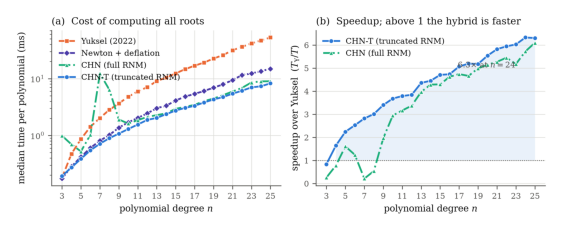

In [16]:
bench_payload = {"real_rooted": sweep, "mixed": mixed}
robust_payload = {"seed_sweep": robust_seeds, "stall_study": stalls}

figures.figure_performance(bench_payload)
figures.figure_accuracy(bench_payload)
figures.figure_coverage(bench_payload)
figures.figure_truncation(robust_payload)
figures.figure_robustness(robust_payload)

fig, ax = plt.subplots(figsize=(7.0, 3.2))
img = plt.imread("figures/fig_performance.png")
ax.imshow(img)
ax.axis("off")
plt.show()

## 11. Test suite

The claims above are asserted as tests, so a change that breaks one of them
fails loudly rather than quietly producing wrong numbers.

In [17]:
import subprocess

completed = subprocess.run(
    [sys.executable, "test_chn_solvers.py"], capture_output=True, text=True
)
print(completed.stdout[-1500:])
assert completed.returncode == 0, "test suite failed"


PASS  test_all_roots_competitive_with_lapack
PASS  test_backward_error_is_machine_level
PASS  test_chn_monotone_modulus
PASS  test_complex_roots_recovered
PASS  test_kalantari_bound_contains_roots
PASS  test_rnm_strictly_decreases_modulus
PASS  test_smale_cycle_is_broken
PASS  test_taylor_coefficients
PASS  test_truncated_matches_full
PASS  test_wilkinson_like
PASS  test_yuksel_finds_real_roots

11/11 passed



## Summary

| Claim | Evidence |
|---|---|
| CHN-T is faster than Yuksel's method for $n \ge 4$, up to 6.7× at $n=25$ | Section 7 |
| Both hybrids are backward stable and match LAPACK's forward error | Sections 6–7 |
| The modulus decreases strictly, so the iteration cannot cycle | Sections 5, 8 |
| Newton fails outright on $z^3-2z+2$; the hybrids do not | Sections 8–9 |
| Yuksel returns about half the roots when complex roots are present | Section 7 |
| The truncated fallback needs $m \le 2$ over 99% of the time | Section 8 |

### Citing

> B. Kalantari, *Polynomial Root-Finding and Polynomiography*, World Scientific, 2008.
>
> B. Kalantari, "A geometric modulus principle for polynomials",
> *Amer. Math. Monthly* 118 (2011) 931–935.
>
> B. Kalantari, "An infinite family of bounds on zeros of analytic functions and
> an application to Newton's method", *Math. Comp.* 74 (2005) 841–852.
>
> B. Kalantari, "A globally convergent Newton method for polynomials",
> arXiv:2003.00372; revised version forthcoming.
>
> B. Kalantari, "Invitation to polynomiography via ChatGPT and a course on
> computational thinking", *LASER Journal* 3(1), Art. 3, 2025.
>
> C. Yuksel, "High-performance polynomial root finding for graphics",
> *Proc. ACM Comput. Graph. Interact. Tech.* 5(3), 2022.